In [ ]:
 !pip install xlstm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.2 MB/s eta 0:00:00


In [ ]:
from omegaconf import OmegaConf
from pprint import pprint
from dacite import from_dict
from dacite import Config as DaciteConfig
import torch
from xlstm.xlstm_block_stack import xLSTMBlockStack, xLSTMBlockStackConfig


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd drive/MyDrive/ex_comparison_forecasting

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ex_comparison_forecasting


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import norm
import math
import sklearn.preprocessing
import pickle
from scipy import interpolate
import random
import time
# import optuna
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2

import argparse
import torch
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import pandas as pd
import torch
import torch.nn as nn
from torch.nn.utils import weight_norm


In [ ]:
# !pip install openseespy

In [ ]:
file_name = 'nonscalenew_p_data_PINN_ex1.p'

### Run OpenSeesPy

In [ ]:
# !pip install openseespy
# import openseespy.opensees as ops

In [ ]:
m = 1 # kg
Tn = 0.7  # s
zeta = 0.02
wn = 2*3.14/Tn
K = m*wn**2
C = 2*m*wn*zeta
C, K

(0.3588571428571429, 80.4865306122449)

In [ ]:

# Nsample = 1000
# # list_ground = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 23, 25, 27, 29, 31, 33, 34, 35, 37, 39, 43, 45, 46, 50]
# list_ground = [1, 2, 3, 4, 5,  8, 9, 11, 13, 14, 20, 25, 27, 33, 34, 37]

# with open('GMfiles/EQall.p', 'rb') as f:
#   dfEQ = pickle.load(f)


# m = 1 # kg
# Tn = 0.7  # s
# zeta = 0.02
# intensity = 0.5
# Nsample = 1000
# list_name=['m', 'Tn', 'zeta', 'intensity']
# dict_type = {'m':'normal', 'Tn':'log', 'zeta':'log', 'intensity':'normal'}
# dict_cov = {'m':0.1, 'Tn':0.1, 'zeta':0.15, 'intensity':0.1}
# dict_variable = {}
# for k in list_name:
#     if dict_type[k] == 'normal':
#         dict_variable[k] = np.random.normal(1.0, dict_cov[k], Nsample)
#     elif dict_type[k] == 'log':
#         mean = 1.0
#         std =  dict_cov[k]
#         sigmal = np.sqrt(np.log(std**2/mean**2 + 1))
#         mu = np.log(mean) - sigmal**2/2
#         dict_variable[k] = np.random.lognormal(mu, sigmal, Nsample)

# df = pd.DataFrame.from_dict(dict_variable)
# list_a, list_v, list_u = [], [], []
# list_motion, list_f, list_mck = [], [], []
# list_dt, list_name = [], []
# list_C, list_K = [], []
# list_EQ = []
# for i in range(1000):
#     i_ground = list_ground[random.randint(0, len(list_ground)-1)]
#     ops.wipe()
#     ops.model('basic','-ndm',1,'-ndf',1)

#     g = 9.810
#     pi = 3.14159
#     m = df['m'][i] # kg
#     Tn = df['Tn'][i]  # s
#     zeta = df['zeta'][i]
#     intensity = df['intensity'][i]

#     wn = 2*pi/Tn
#     K = m*wn**2
#     C = 2*m*wn*zeta

#     ops.node(1,0); ops.fix(1,1)
#     ops.node(2,0); ops.mass(2,m)

#     ops.uniaxialMaterial('Elastic',1,K,C)
#     ops.element('zeroLength',1,1,2,'-mat',1,'-dir',1)

#     # ops.timeSeries('Path',1,'-dt',0.01,'-filePath','TakY.th','-factor',intensity*g)
#     ops.timeSeries('Path',1,'-dt', dfEQ['dt (s)'][i_ground],'-filePath',f'GMfiles/{dfEQ['Ground motions'][i_ground]}','-factor',intensity*g)
#     ops.pattern('UniformExcitation',1,1,'-accel',1)

#     ops.recorder('Node','-file','displacement2.txt','-time','-node',2,'-dof',1,'disp')
#     ops.recorder('Node','-file','velo2.txt','-time','-node',2,'-dof',1,'vel')
#     ops.recorder('Node','-file','acc2.txt','-time','-node',2,'-dof',1,'accel')

#     ops.analysis('Transient','-noWarnings')
#     ops.analyze(3000,0.01)

#     du2 = pd.read_csv('displacement2.txt', sep=r'\s+',header=None)
#     dv2 = pd.read_csv('velo2.txt', sep=r'\s+',header=None)
#     da2 = pd.read_csv('acc2.txt', sep=r'\s+',header=None)
#     u = du2[1].values*1000
#     v = dv2[1].values*1000
#     a = da2[1].values*1000
#     gg = dfEQ['gEQ_FEM'][i_ground]*1000
#     f = 9.81*intensity*gg*m
#     if len(f)<3000:
#         f = np.append(f, [0]*(3000-len(f)))
#     mck = m*a + C*v  + K*u
#     dt = dfEQ['dt (s)'][i_ground]
#     list_a.append(a)
#     list_v.append(v)
#     list_u.append(u)
#     list_C.append(C)
#     list_K.append(K)
#     list_motion.append(gg[:3000])
#     list_f.append(f[:3000])
#     list_mck.append(mck)
#     list_dt.append(dt)
#     list_EQ.append(i_ground)


# df['a'] = list_a
# df['v'] = list_v
# df['u'] = list_u
# df['f'] = list_f
# df['C'] = list_C
# df['K'] = list_K
# df['mck'] = list_mck
# df['dt'] = list_dt
# df['disp_ground'] = list_motion
# df['idEQ'] = list_EQ

# with open(file_name, 'wb') as f:
#     pickle.dump(df, f)


### DL model

In [ ]:

with open(file_name, 'rb') as f:
  df_new = pickle.load(f)

list(df_new)

['m',
 'Tn',
 'zeta',
 'intensity',
 'a',
 'v',
 'u',
 'f',
 'C',
 'K',
 'mck',
 'dt',
 'disp_ground',
 'idEQ']

### DL model

In [ ]:
with open('GMfiles/EQall.p', 'rb') as f:
  dfEQ = pickle.load(f)

with open(file_name, 'rb') as f:
  df_new = pickle.load(f)

for i in range(1000):
  LL = len(df_new['disp_ground'][i])
  if len(df_new['disp_ground'][i]) < 3000:
    df_new['disp_ground'][i] = list(df_new['disp_ground'][i])+[0]*(3000-LL)


df_new.rename(columns={'a': 'disp_1', 'v':'disp_2', 'u':'disp_3', 'mck':'disp_mckd'}, inplace=True)
df_new.drop(['f', 'dt'], axis=1, inplace=True)

for i in range(len(df_new)):
  L = len(df_new['disp_2'][i])

len(df_new)

1000

In [ ]:
def getPositionEncoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return P


In [ ]:
list_output_time = []
list_static = []

for k in list(df_new):
  if (str(k)[:4] == 'disp') & (str(k)[-1] != 'd'):
    list_output_time.append(k)

  if str(k)[:4] != 'disp':
    list_static.append(k)

list_mck = ['disp_mckd']

print(list_static)
print(list_output_time)


['m', 'Tn', 'zeta', 'intensity', 'C', 'K', 'idEQ']
['disp_1', 'disp_2', 'disp_3']


In [ ]:
L_signal_input = len(df_new['disp_2'][0])
L_ground = L_signal_input

Ndim_encoding = 2
P_encoding = getPositionEncoding(seq_len=L_signal_input, d=Ndim_encoding, n=10000)
list_input_time = ['disp_ground', 'encode_0', 'encode_1']


print(list_input_time)
print(list_output_time)

['disp_ground', 'encode_0', 'encode_1']
['disp_1', 'disp_2', 'disp_3']


In [ ]:
for d in range(Ndim_encoding):
  df_new[f'encode_{d}'] = [P_encoding[:,d]]*len(df_new)


In [ ]:
L_all, L_out = 150, 100
sliding_step = L_out
list_time_series = list_input_time + list_output_time
L_in = L_all-L_out
N_input= len(list_input_time)
N_output= len(list_output_time)
N_static = len(list_static)
N_all = N_input+N_output+N_static
N_time_series = len(list_input_time)+len(list_output_time)+1

max_disp = [np.max(np.abs(df_new[list_output_time[-1]][idx])) for idx in range(len(df_new))]
df_new['max_disp'] = max_disp


In [ ]:
# static_scaler = sklearn.preprocessing.StandardScaler().fit(df_new[list_static].values)
# target = np.array([df_new[i][0] for i in list_output_time]).T
# target_scaler = sklearn.preprocessing.StandardScaler().fit(target)
# real = np.array([df_new[i][0] for i in list_time_series]).T
# real_scaler = sklearn.preprocessing.StandardScaler().fit(real)

In [ ]:
target = np.array([df_new[i][0] for i in list_output_time]).T
target_mean0 = np.mean(target,axis=0)
target_std0 = np.std(target,axis=0)


In [ ]:
def prepare_data_batch(x, N1, N2, j = 2, list_feature=list_output_time):
  N0 = np.shape(x)[1]
  xxx = np.stack([x[:,i:N0 - N1+i+1:j, :] for i in range(N1)], axis=2)
  y = xxx[:,:,-N2:,-len(list_feature):]

  return np.array(xxx), np.array(y)

In [ ]:
gc.collect(2)
gc.collect(2)

0

In [ ]:
class h_Dataset(Dataset):
    def __init__(self, data_time, data_static, data_y, data_mck):
        self.data_time = data_time
        self.data_static = data_static
        self.data_y = data_y
        self.data_mck = data_mck

    def __getitem__(self, index):
        seq_time = self.data_time[index]
        seq_static = self.data_static[index]
        seq_y = self.data_y[index]
        seq_mck = self.data_mck[index]
        return seq_time, seq_static, seq_y, seq_mck

    def __len__(self):
        return len(self.data_y)


def data_provider2(data_time, data_static, data_y, data_mck, batch_size=128):
    data_set = h_Dataset(data_time, data_static, data_y, data_mck)
    data_loader = DataLoader(data_set, batch_size=batch_size, shuffle=True, drop_last=True)
    return data_set, data_loader


In [ ]:
class Data_aggregation(nn.Module):
    def __init__(self, dropout=0.1):
        super(Data_aggregation, self).__init__()
        self.projection = nn.Sequential(nn.Linear(N_static, L_all), nn.ReLU(), nn.Linear(L_all, L_all))
        self.dropout = nn.Dropout(p=0.1)
        self.layer_norm_static = nn.LayerNorm(normalized_shape=N_static)
        self.layer_norm_time = nn.LayerNorm(normalized_shape=N_time_series-1)
        # self.batch_norm = nn.BatchNorm1d(N_time_series)

    def forward(self, x_time, x_static):
        x = self.layer_norm_static(x_static)
        x = self.projection(x_static)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        x_time = self.layer_norm_time(x_time)
        x = torch.cat([x_time, x], dim=2)
        # x = self.batch_norm(x.permute(0, 2, 1)).permute(0, 2, 1)

        return x

In [ ]:
# [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
def gen_data_AI_batch_2_model(df_new, list_idx):
  signal = [np.stack(list(df_new[k][list_idx])) for k in list_time_series ]
  signal = np.stack(signal).transpose(1,2,0)
  signal = np.pad(signal,((0,0),(L_all,0),(0,0)),constant_values=0.0)
  signal = signal.reshape(-1, N_input + N_output)
  # scaled_signal = real_scaler.transform(signal)
  scaled_signal = signal
  scaled_signal = scaled_signal.reshape(-1, L_ground+L_all, N_input + N_output)
  X_times_series, Y_label = prepare_data_batch(scaled_signal, L_all, L_out, j = sliding_step)
  X_times_series[:,:,L_in:,N_input:N_input+N_output] = 0.0

  static = np.stack(list(df_new[k][list_idx] for k in list_static)).T
  # scaled_static = static_scaler.transform(static)
  scaled_static = static
  X_static = scaled_static.reshape(-1,1,1,N_static)
  X_static = np.tile(X_static, [1, X_times_series.shape[1], 1, 1])
  X_times_series = X_times_series.reshape(-1, L_all, N_input+N_output)
  X_static = X_static.reshape(-1, 1, N_static)
  Y_label =  Y_label.reshape(-1, L_out, N_output)


  signal = [np.stack(list(df_new[k][list_idx])) for k in list_mck ]
  signal = np.stack(signal).transpose(1,2,0)
  signal = np.pad(signal,((0,0),(L_all,0),(0,0)),constant_values=0.0)
  signal = signal.reshape(-1, 1)
  scaled_signal = signal
  scaled_signal = scaled_signal.reshape(-1, L_ground+L_all, 1)
  X_mck, _ = prepare_data_batch(scaled_signal, L_all, L_out, j = sliding_step, list_feature=list_mck)
  X_mck = X_mck.reshape(-1, L_all, len(list_mck))

  return X_times_series, X_static, Y_label, X_mck




In [ ]:
def data_provider2(data_time, data_static, data_y, data_mck, batch_size=128):
    data_set = h_Dataset(data_time, data_static, data_y, data_mck)
    data_loader = DataLoader(data_set, batch_size=batch_size, shuffle=True, drop_last=True)
    return data_set, data_loader

def loader_data(df_new, idx_train, batch_size = 128):
  list_train_time, list_train_static, list_train_label, list_train_mck = [], [], [], []
  list_val_time, list_val_static, list_val_label, list_val_mck = [], [], [], []
  time, static, label, mck = gen_data_AI_batch_2_model(df_new, idx_train)
  list_train_time.append(time)
  list_train_static.append(static)
  list_train_label.append(label)
  list_train_mck.append(mck)

  train_time = np.concatenate(list_train_time, axis=0)
  train_static = np.concatenate(list_train_static, axis=0)
  train_label = np.concatenate(list_train_label, axis=0)
  train_mck = np.concatenate(list_train_mck, axis=0)
  _, train_loader = data_provider2(train_time, train_static, train_label, train_mck, batch_size=batch_size)

  return train_loader


In [ ]:
idx_train = np.random.choice(len(df_new), size=256, replace=False)
idx_val = np.array([i for i in range(len(df_new)) if i not in idx_train])
idx_val = idx_val[:256]

train_loader= loader_data(df_new, idx_train, batch_size = 256)
valid_loader = loader_data(df_new, idx_val, batch_size = 256)

In [ ]:

def inference_5tor(model, aggregation, df_new, list_idx, batch_size = 512):
  x_time, x_static, _, _ = gen_data_AI_batch_2_model(df_new, list_idx)
  x_time = x_time.reshape(len(list_idx),-1,L_all, N_input+N_output)
  x_static = x_static.reshape(len(list_idx),-1, 1, N_static)
  # initial a long output time-series with zero
  y_predict_all = np.zeros((len(x_time), L_ground+L_all, N_output))
  for j in range(int(L_ground/L_out)+1):
    x_time[:,j,:L_all, N_input:N_input+N_output] = y_predict_all[:,L_out*j:L_all+L_out*j,:]
    xt = torch.from_numpy(x_time[:,j,:,:]).float().to('cuda')
    xs = torch.from_numpy(x_static[:,j,:,:]).float().to('cuda')
    batch_x = aggregation(xt, xs)
    y_pred_all = model(batch_x)
    target_mean = torch.tensor(target_mean0).to(device)
    target_mean = target_mean[None, None, :].expand(y_pred_all.shape)
    target_std = torch.tensor(target_std0).to(device)
    target_std = target_std[None, None, :].expand(y_pred_all.shape)
    y_pred_all = y_pred_all*target_std + target_mean
    y_pred_all = y_pred_all.to('cuda').cpu().detach().numpy()
    y_predict_all[:,L_in+L_out*j:L_all+L_out*j,:] = y_pred_all[:,:,:]

  # y_predict_all = target_scaler.inverse_transform(y_predict_all.reshape(-1, N_output))
  y_predict_all = y_predict_all.reshape(len(x_time), -1, N_output)

  return y_predict_all

In [ ]:
class model_parameters:
  def __init__(self):
    self.d_model = 128
    self.e_layers = 2
    self.dropout = 0.1

args = model_parameters()


In [ ]:
xlstm_cfg = f"""
mlstm_block:
  mlstm:
    conv1d_kernel_size: 3
    qkv_proj_blocksize: 4
    num_heads: 1
slstm_block:
  slstm:
    backend: {'cuda' if torch.cuda.is_available() else 'vanilla'}
    num_heads: 1
    conv1d_kernel_size: 3
    bias_init: powerlaw_blockdependent
  feedforward:
    proj_factor: 1.3
    act_fn: gelu
context_length: {L_all}
num_blocks: 1
embedding_dim: {N_input+N_output+1}
slstm_at: []
"""

cfg = OmegaConf.create(xlstm_cfg)
cfg = from_dict(data_class=xLSTMBlockStackConfig, data=OmegaConf.to_container(cfg), config=DaciteConfig(strict=True))
xlstm_stack = xLSTMBlockStack(cfg)


In [ ]:
class ResBlock(nn.Module):
    def __init__(self, configs):
        super(ResBlock, self).__init__()
        self.temporal = nn.Sequential(nn.Linear(L_all, configs.d_model), nn.ReLU(), nn.Linear(configs.d_model, L_all), nn.Dropout(configs.dropout))
        self.channel = nn.Sequential(nn.Linear(N_input+N_output+1, configs.d_model), nn.ReLU(), nn.Linear(configs.d_model, N_input+N_output+1), nn.Dropout(configs.dropout))
        self.layer_norm_1 = nn.LayerNorm(normalized_shape=N_input+N_output+1)
        self.layer_norm_2 = nn.LayerNorm(normalized_shape=N_input+N_output+1)

    def forward(self, x):
        # x: [B, L, D]
        x = x + self.temporal(x.transpose(1, 2)).transpose(1, 2)
        x = self.layer_norm_1(x)
        x = x + self.channel(x)
        x = self.layer_norm_2(x)
        return x



class TSMixer_dis(nn.Module):
    def __init__(self, configs):
        super(TSMixer_dis, self).__init__()
        self.layer = configs.e_layers
        self.model = nn.ModuleList([ResBlock(configs) for _ in range(configs.e_layers)])
        self.Lmodel = xLSTMBlockStack(cfg)
        self.projection = nn.Sequential(nn.Linear(L_all, L_out), nn.ReLU())
        self.out_layer = nn.Linear(N_input+N_output+1, N_output, bias=False)
        # self.layer_norm_proj = nn.LayerNorm(normalized_shape=N_input+N_output+1)
        # self.batch_norm = nn.BatchNorm1d(N_time_series)

    def forward(self, x_enc):
        x = x_enc
        for i in range(self.layer):
            x = self.model[i](x)
        # x = self.batch_norm(x.permute(0, 2, 1)).permute(0, 2, 1)


        x = self.Lmodel(x)
        x = self.projection(x.permute(0, 2, 1)).permute(0, 2, 1)
        # x = self.layer_norm_proj(x)
        x_out = self.out_layer(x)
        return x_out



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_mean = torch.tensor(target_mean0).to(device)
target_mean = target_mean[None, None, :].expand(256, 100, 3)
target_std = torch.tensor(target_std0).to(device)
target_std = target_std[None, None, :].expand(256, 100, 3)


In [ ]:
aggregation = Data_aggregation().float().to(device)
model_tor = TSMixer_dis(args).float().to(device)
model_optim = torch.optim.Adam(list(model_tor.parameters())+list(aggregation.parameters()), lr=0.001)
criterion = nn.L1Loss()
list_train_loss_M = []
list_val_loss_M = []

seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)


In [ ]:
with open('non_local_PINNex1_xlstm_good.p','rb') as f:
  y_predict_all = pickle.load(f)
  y_ref = pickle.load(f)
  idx_train = pickle.load(f)
  idx_val = pickle.load(f)
  list_train_loss_M = pickle.load(f)
  list_val_loss_M = pickle.load(f)
  model_tor = pickle.load(f)
  aggregation = pickle.load(f)



# %%time
# list_lr = [0.001]
# # list_lr = [0.001]
# Nm = 1
# identity_matrix = torch.eye(Nm).to(device)
# for lr in list_lr:
#   model_optim = torch.optim.Adam(list(model_tor.parameters())+list(aggregation.parameters()), lr=lr)
#   N_epoch = 51
#   for epoch in range(N_epoch):
#       train_loss = []
#       for batch_time, batch_static, batch_y, batch_F in train_loader:
#           model_optim.zero_grad()
#           batch_time, batch_static, batch_y, batch_F = batch_time.float().to(device), batch_static.float().to(device), batch_y.float().to(device), batch_F.float().to(device)
#           batch_x = aggregation(batch_time, batch_static)
#           x_tt = model_tor(batch_x)
#           x_tt = x_tt*target_std + target_mean

#           list_mm = batch_static[:,0,:Nm]
#           list_cc = batch_static[:,0,Nm:Nm*2]
#           list_kx = batch_static[:,0,Nm*2:Nm*3]
#           M_ = torch.einsum('bi,ij->bij', list_mm, identity_matrix)
#           C_ = torch.einsum('bi,ij->bij', list_cc, identity_matrix)
#           K_ = torch.einsum('bi,ij->bij', list_kx, identity_matrix)
#           for i in range(Nm-1):
#             K_[:,i,i] += list_kx[:,i+1]
#             K_[:,i,i+1] = -list_kx[:,i+1]
#             K_[:,i+1,i] = -list_kx[:,i+1]

#           for i in range(Nm-1):
#             C_[:,i,i] += list_cc[:,i+1]
#             C_[:,i,i+1] = -list_cc[:,i+1]
#             C_[:,i+1,i] = -list_cc[:,i+1]

#           x_mck     = torch.einsum('bij,bLj->bLi', M_, x_tt[:,:,:Nm]) + torch.einsum('bij,bLj->bLi', C_, x_tt[:,:,Nm:2*Nm])+ torch.einsum('bij,bLj->bLi', K_, x_tt[:,:,2*Nm:3*Nm])
#           # batch_mck = torch.einsum('bij,bLj->bLi', M_, batch_y[:,:,:Nm]) + torch.einsum('bij,bLj->bLi', C_, batch_y[:,:,Nm:2*Nm])+ torch.einsum('bij,bLj->bLi', K_, batch_y[:,:,2*Nm:3*Nm])
#           iloss = 1
#           loss =  criterion(torch.einsum('bij,bLj->bLi', M_, x_tt[:,::iloss,:Nm]), torch.einsum('bij,bLj->bLi', M_,       batch_y[:,::iloss,:Nm])) \
#                 + criterion(torch.einsum('bij,bLj->bLi', C_, x_tt[:,::iloss,Nm:2*Nm]), torch.einsum('bij,bLj->bLi', C_,   batch_y[:,::iloss,Nm:2*Nm])) \
#                 + criterion(torch.einsum('bij,bLj->bLi', K_, x_tt[:,::iloss,2*Nm:3*Nm]), torch.einsum('bij,bLj->bLi', K_, batch_y[:,::iloss,2*Nm:3*Nm])) \
#                 + criterion(x_mck, batch_F[:,-L_out:,:])

#           loss.backward()
#           train_loss.append(loss.item())
#           model_optim.step()

#       if epoch % 5 ==0:
#         valid_loss = []
#         for batch_time, batch_static, batch_y, batch_F in valid_loader:
#           batch_time, batch_static, batch_y, batch_F = batch_time.float().to(device), batch_static.float().to(device), batch_y.float().to(device), batch_F.float().to(device)
#           batch_x = aggregation(batch_time, batch_static)
#           x_tt = model_tor(batch_x)
#           x_tt = x_tt*target_std + target_mean

#           list_mm = batch_static[:,0,:Nm]
#           list_cc = batch_static[:,0,Nm:Nm*2]
#           list_kx = batch_static[:,0,Nm*2:Nm*3]
#           M_ = torch.einsum('bi,ij->bij', list_mm, identity_matrix)
#           C_ = torch.einsum('bi,ij->bij', list_cc, identity_matrix)
#           K_ = torch.einsum('bi,ij->bij', list_kx, identity_matrix)
#           for i in range(Nm-1):
#             K_[:,i,i] += list_kx[:,i+1]
#             K_[:,i,i+1] = -list_kx[:,i+1]
#             K_[:,i+1,i] = -list_kx[:,i+1]

#           for i in range(Nm-1):
#             C_[:,i,i] += list_cc[:,i+1]
#             C_[:,i,i+1] = -list_cc[:,i+1]
#             C_[:,i+1,i] = -list_cc[:,i+1]

#           x_mck     = torch.einsum('bij,bLj->bLi', M_, x_tt[:,:,:Nm]) + torch.einsum('bij,bLj->bLi', C_, x_tt[:,:,Nm:2*Nm])+ torch.einsum('bij,bLj->bLi', K_, x_tt[:,:,2*Nm:3*Nm])
#           loss =  criterion(torch.einsum('bij,bLj->bLi', M_, x_tt[:,:,:Nm]), torch.einsum('bij,bLj->bLi', M_, batch_y[:,:,:Nm])) \
#                 + criterion(torch.einsum('bij,bLj->bLi', C_, x_tt[:,:,Nm:2*Nm]), torch.einsum('bij,bLj->bLi', C_, batch_y[:,:,Nm:2*Nm])) \
#                 + criterion(torch.einsum('bij,bLj->bLi', K_, x_tt[:,:,2*Nm:3*Nm]), torch.einsum('bij,bLj->bLi', K_, batch_y[:,:,2*Nm:3*Nm])) #\
#                 # + criterion(x_mck, batch_F)

#           valid_loss.append(loss.item())

#         print(f"epoch: {epoch} | loss: {np.mean(train_loss)}, valid loss: {np.mean(valid_loss)}")
#         list_train_loss_M.append(np.mean(train_loss))
#         list_val_loss_M.append(np.mean(valid_loss))


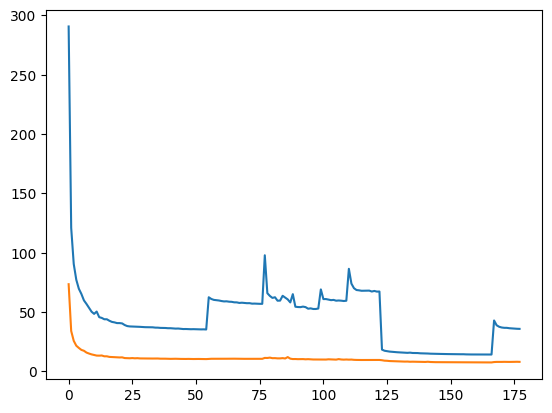

In [ ]:
plt.plot(list_train_loss_M)
plt.plot(list_val_loss_M)

[np.int64(228)]
20
CPU times: user 323 ms, sys: 102 ms, total: 425 ms
Wall time: 968 ms


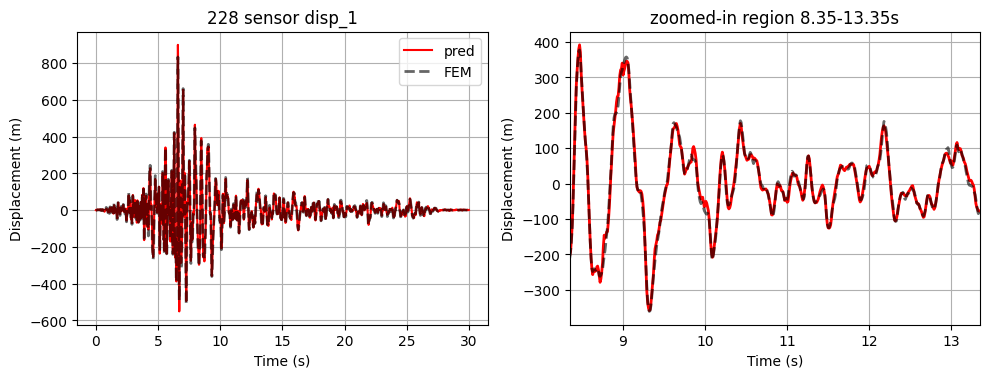

In [ ]:
%%time
plt.figure(figsize=(10,14))

list_ip = [idx_val[np.random.choice(len(idx_val))]]
print(list_ip)
y_predict_all = inference_5tor(model_tor, aggregation, df_new, list_ip)

list_color = ['r', 'orange', 'm', 'g']
for i,ip in enumerate(list_ip):
  plt.subplot(421+i*2)
  i_s = np.random.randint(N_output)
  # i_s = 0
  length = len(df_new[list_output_time[i_s]][ip])
  t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
  plt.plot(t, y_predict_all[i, L_all:L_all+L_ground,i_s][:],list_color[i], linewidth=1.5)
  plt.plot(t, df_new[list_output_time[i_s]][ip][:],'--k', alpha = 0.6, linewidth=2)
  plt.legend(['pred', 'FEM'], loc=0)
  plt.title(f'{ip} sensor {list_output_time[i_s]}', fontsize=12)
  plt.xlabel('Time (s)')
  plt.ylabel('Displacement (m)')
  # plt.ylim(-0.04, 0.04)
  # plt.xlim(0,28)
  plt.grid(True)


  plt.subplot(422+i*2)
  length = len(df_new[list_output_time[i_s]][ip])
  t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
  # t1, t2 = 800, 1200
  t1 = np.random.randint(0,2200)
  t2 = t1+500
  yy = y_predict_all[i, L_all:L_all+length,i_s][:]
  plt.plot(t[t1:t2], yy[t1:t2],list_color[i], linewidth=2)
  yy = df_new[list_output_time[i_s]][ip][:]
  plt.plot(t[t1:t2], yy[t1:t2],'--k', alpha = 0.6, linewidth=2)
  plt.title(f'zoomed-in region {t1/100}-{t2/100}s', fontsize=12)
  plt.xlabel('Time (s)')
  plt.ylabel('Displacement (m)')
  plt.xlim(t1*0.01, t2*0.01)
  plt.grid(True)
  # plt.ylim(-0.042, 0.042)
  print(df_new['idEQ'][ip])

plt.tight_layout();
# plt.savefig(f'{ex_name}_1.png',dpi=400)


In [ ]:
%%time
list_ip = list(range(len(df_new)))
# list_ip = idx_val
y_predict_all = inference_5tor(model_tor, aggregation, df_new, list_ip)


CPU times: user 2.99 s, sys: 265 ms, total: 3.25 s
Wall time: 3.28 s


In [ ]:
y_ref = df_new[list_output_time].values
y_ref = np.array([np.stack(y_ref[i], axis=1) for i in range(len(y_ref))])

In [ ]:
ymax_ref = np.max(np.abs(y_ref[list_ip]), axis=(1))
ymax_pred = np.max(np.abs(y_predict_all), axis=(1))

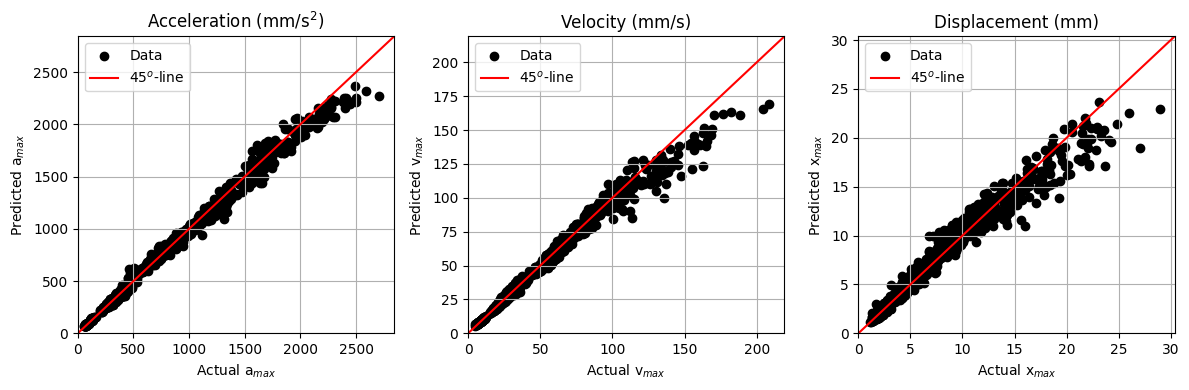

In [ ]:
plt.figure(figsize=(12,4))
list_symbol = ['a','v','x']
list_signal = ['Acceleration', 'Velocity', 'Displacement']
list_unit = ['mm/s$^2$','mm/s','mm']

for i in range(3):
  axs = plt.subplot(131+i)
  vmax = np.max(ymax_ref[:,i])*1.05
  plt.scatter(ymax_ref[:,i], ymax_pred[:,i], color='black')
  plt.plot([0,vmax],[0,vmax],'-r')
  plt.ylabel(f'Predicted {list_symbol[i]}'+'$_{max}$')
  plt.xlabel(f'Actual {list_symbol[i]}'+'$_{max}$')
  plt.title(f'{list_signal[i]} ({list_unit[i]})', fontsize=12)
  plt.grid(True)
  plt.legend(['Data','45$^o$-line'])
  vlim = vmax
  plt.xlim([0,vlim])
  plt.ylim([0,vlim])
  # plt.yticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
  # plt.xticks([0,np.round(vlim//5, decimals=-1), np.round(vlim*2//5, decimals=-1), np.round(vlim*3//5, decimals=-1), np.round(vlim*4//5, decimals=-1), np.round(vlim)])
plt.tight_layout()
# plt.savefig('wall_45.png', dpi=350)



In [ ]:
# with open('non_local_PINNex1_xlstm_good.p','wb') as f:
#   pickle.dump(y_predict_all, f)
#   pickle.dump(y_ref, f)
#   pickle.dump(idx_train, f)
#   pickle.dump(idx_val, f)
#   pickle.dump(list_train_loss_M, f)
#   pickle.dump(list_val_loss_M, f)
#   pickle.dump(model_tor, f)
#   pickle.dump(aggregation, f)



In [ ]:
m_ref = df_new['m'].values
m_ref = np.repeat(m_ref.reshape(-1, 1), repeats=3000, axis=1)
c_ref = df_new['C'].values
c_ref = np.repeat(c_ref.reshape(-1, 1), repeats=3000, axis=1)
k_ref = df_new['K'].values
k_ref = np.repeat(k_ref.reshape(-1, 1), repeats=3000, axis=1)
mck_ref = m_ref * y_ref[:,:,0] + c_ref * y_ref[:,:,1] + k_ref * y_ref[:,:,2]
mck_predict = m_ref * y_predict_all[:,150:,0] + c_ref * y_predict_all[:,150:,1] + k_ref * y_predict_all[:,150:,2]
mck_residual = np.mean(mck_ref - mck_predict, axis=1)

In [ ]:
mck_residual = np.zeros_like(mck_ref, dtype=float)
non_zero_mask = np.where(mck_ref > 1E-9)
mck_residual[non_zero_mask] = ((mck_ref[non_zero_mask] - mck_predict[non_zero_mask]) / np.maximum(np.abs(mck_predict[non_zero_mask]),np.abs(mck_ref[non_zero_mask])) * 100)


In [ ]:
mck_residual = np.mean(mck_residual, axis=1)
mck_residual.shape

(1000,)

In [ ]:
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.sans-serif'] = ['Time New Roman']
fsize = 12
rcParams.update({'font.size': fsize})

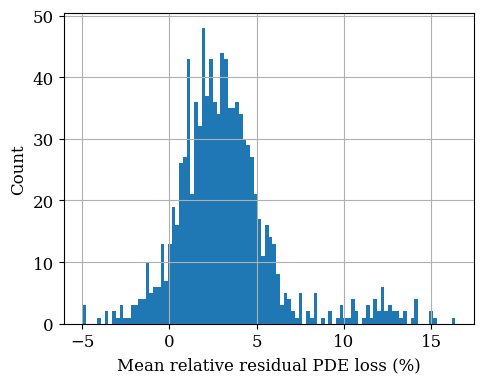

In [ ]:
plt.figure(figsize=(5,4))
plt.hist(mck_residual,bins=100);
plt.ylabel('Count')
plt.xlabel(f'Mean relative residual PDE loss (%)')
plt.grid(True)
plt.tight_layout()


In [ ]:
np.mean(mck_residual), np.std(mck_residual)

(np.float64(3.1789012867549165), np.float64(2.922000044078014))

In [ ]:
mck_residual = np.zeros_like(mck_ref, dtype=float)
non_zero_mask = np.where(mck_ref > -1E9)
mck_residual[non_zero_mask] = ((mck_ref[non_zero_mask] - mck_predict[non_zero_mask]) / mck_ref[non_zero_mask] * 100)

In [ ]:
plt.hist(mck_residual.reshape(-1),bins=100);

In [ ]:
gf = 9.81*intensity*gg*m
mck = m*a + C*v  + K*u
plt.plot(-f[1:][:len(mck)-2],'-r')
plt.plot(mck[0:-2],'--k')
plt.legend(['m*ag', 'm*a + C*v  + K*u'])
plt.title(dfEQ['Name'][i_ground])
plt.show()

In [ ]:
identity_matrix = torch.eye(Nm)
for batch_time, batch_static, batch_y, batch_mck in train_loader:
    list_mm = batch_static[:,0,:Nm]
    list_cc = batch_static[:,0,Nm:Nm*2]
    list_kx = batch_static[:,0,Nm*2:Nm*3]
    M_ = torch.einsum('bi,ij->bij', list_mm, identity_matrix)
    C_ = torch.einsum('bi,ij->bij', list_cc, identity_matrix)
    K_ = torch.einsum('bi,ij->bij', list_kx, identity_matrix)
    for i in range(Nm-1):
      K_[:,i,i] += list_kx[:,i+1]
      K_[:,i,i+1] = -list_kx[:,i+1]
      K_[:,i+1,i] = -list_kx[:,i+1]

    for i in range(Nm-1):
      C_[:,i,i] += list_cc[:,i+1]
      C_[:,i,i+1] = -list_cc[:,i+1]
      C_[:,i+1,i] = -list_cc[:,i+1]

    batch_mckkk = torch.einsum('bij,bLj->bLi', M_, batch_y[:,:,:Nm]) + torch.einsum('bij,bLj->bLi', C_, batch_y[:,:,Nm:2*Nm])+ torch.einsum('bij,bLj->bLi', K_, batch_y[:,:,2*Nm:3*Nm])
    break

In [ ]:
batch_mck.shape, batch_mckkk.shape

(torch.Size([256, 150, 1]), torch.Size([256, 100, 1]))

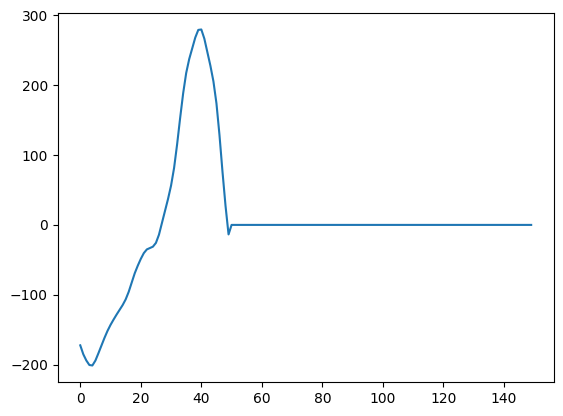

In [ ]:
ii = 100
plt.plot(batch_mck[ii,:,0])
# plt.plot(batch_mckkk[ii,-100:,0])